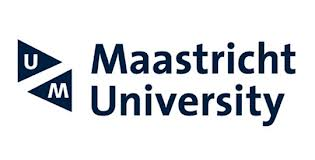



# Information Retrieval and Text Mining Course
## Tutorial 04 — Dense Retrieval and Semantic Search

**Author:** Jan Scholtes

**Edition 2026-2027**

Department of Advanced Computer Sciences — Maastricht University

## Introduction

Welcome to Tutorial 04 on **Dense Retrieval and Semantic Search**. In Tutorial 02 you learned about document representations (TF-IDF, Word2Vec, embeddings). In Tutorial 03 you learned how to measure the quality of retrieval systems. Now we put these concepts together to build **semantic search** systems that understand *meaning*, not just keywords.

### What You Will Learn

1. **Dense Retrieval Fundamentals** — How neural embeddings capture semantic similarity
2. **Bi-Encoders vs Cross-Encoders** — Two architectures for neural ranking
3. **FAISS for Efficient Search** — Approximate nearest neighbor search at scale
4. **Hybrid Retrieval** — Combining sparse (BM25) and dense (embeddings) approaches
5. **Evaluation** — Applying Tutorial 03 metrics (nDCG, MRR, Recall@K)

### The Lexical Gap Problem

Traditional keyword-based search (like BM25) fails when queries and documents use different words for the same concept:

| Query | Relevant Document | Problem |
|-------|------------------|----------|
| "laptop computer" | "portable notebook PC" | Different vocabulary |
| "What is AI?" | "Artificial intelligence is..." | Abbreviation |
| "car repair" | "automobile maintenance" | Synonyms |

**Dense retrieval** solves this by encoding queries and documents into **vector representations** where semantically similar text has similar vectors, regardless of exact word overlap.

### Course Context

This tutorial prepares you for **Assignment 03** (Complete Search Engine Pipeline), where you will combine sparse retrieval, dense retrieval, and neural reranking into a production-grade system. It also prepares you for **conversational search** (Tutorials 09-12), where semantic understanding is essential.

## GPU Check

Dense retrieval benefits from GPU acceleration when encoding large collections. Let's verify your GPU setup:

In [ ]:
import torch
import sys

print("=" * 70)
print("GPU AVAILABILITY CHECK")
print("=" * 70)

print(f"\nPython version: {sys.version}")
print(f"PyTorch version: {torch.__version__}")

cuda_available = torch.cuda.is_available()
print(f"\nCUDA available: {cuda_available}")

if cuda_available:
    print(f"CUDA version: {torch.version.cuda}")
    print(f"cuDNN version: {torch.backends.cudnn.version()}")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    for i in range(torch.cuda.device_count()):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")
        props = torch.cuda.get_device_properties(i)
        print(f"    Memory: {props.total_memory / 1024**3:.1f} GB")
        print(f"    Compute Capability: {props.major}.{props.minor}")
else:
    print("\n⚠️  No GPU detected. Dense retrieval will run on CPU.")
    print("   Encoding speed will be slower but results will be identical.")

# Set device
device = torch.device('cuda' if cuda_available else 'cpu')
print(f"\nUsing device: {device}")
print("=" * 70)

## Library Installation

We need the following packages:
- `sentence-transformers`: Pre-trained bi-encoder models (SBERT)
- `faiss-cpu` or `faiss-gpu`: Efficient similarity search
- `scikit-learn`: Metrics and utilities
- `datasets`: HuggingFace datasets (for MS MARCO subset)

In [ ]:
# Install required packages (skips already-installed ones)
import subprocess, sys, importlib

packages = {
    "sentence-transformers": "sentence_transformers",
    "faiss-cpu": "faiss",
    "scikit-learn": "sklearn",
    "datasets": "datasets",
}

to_install = [pip_name for pip_name, import_name in packages.items()
               if importlib.util.find_spec(import_name) is None]

if to_install:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *to_install])
    print(f"Installed: {', '.join(to_install)}")
else:
    print("All packages already installed — nothing to do.")

In [ ]:
# Import libraries
import numpy as np
import faiss
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from datasets import load_dataset
import time
from collections import defaultdict
import warnings

warnings.filterwarnings('ignore')

print("✓ All libraries imported successfully")

## 1. Dense Retrieval Fundamentals

### 1.1 How Dense Retrieval Works

Dense retrieval uses **neural encoders** to map text into fixed-size vectors:

```
Text → Encoder (BERT/SBERT) → Vector (e.g., 384-dim)
```

Retrieval becomes **vector similarity**:

$$
\text{score}(q, d) = \text{sim}(\mathbf{v}_q, \mathbf{v}_d) = \frac{\mathbf{v}_q \cdot \mathbf{v}_d}{\|\mathbf{v}_q\| \|\mathbf{v}_d\|}
$$

Where:
- $\mathbf{v}_q$ = query vector
- $\mathbf{v}_d$ = document vector
- $\text{sim}$ = cosine similarity (or dot product if normalized)

### 1.2 Bi-Encoders vs Cross-Encoders

There are two main architectures for neural ranking:

| | **Bi-Encoder** | **Cross-Encoder** |
|---|---|---|
| **Architecture** | Separate encoders for query and document | Joint encoder for [query, document] |
| **Encoding** | Independent: $f(q)$, $f(d)$ | Joint: $f([q, d])$ |
| **Scoring** | Cosine similarity | Classification head |
| **Speed** | Fast (pre-compute doc vectors) | Slow (score each pair) |
| **Accuracy** | Good | Better |
| **Use case** | **First-stage retrieval** | **Reranking** |

**This tutorial focuses on bi-encoders** because they enable efficient search over millions of documents. Cross-encoders will appear in Assignment 03 (reranking).

### 1.3 Sentence-BERT (SBERT)

**SBERT** ([Reimers & Gurevych, 2019](https://arxiv.org/abs/1908.10084)) is a modification of BERT optimized for sentence embeddings:

1. **Mean pooling** instead of just `[CLS]` token
2. **Siamese network** training on sentence pairs
3. **Contrastive loss** to make similar sentences closer

Popular pre-trained models:
- `all-MiniLM-L6-v2` (384-dim, fast, good quality)
- `all-mpnet-base-v2` (768-dim, slower, better quality)
- `multi-qa-MiniLM-L6-cos-v1` (384-dim, tuned for Q&A)

We use `all-MiniLM-L6-v2` as a good speed/quality tradeoff.

## 2. Building a Dense Retrieval System

Let's build a simple dense retrieval system step-by-step.

### 2.1 Load a Pre-trained Bi-Encoder

In [ ]:
# Load bi-encoder model
model_name = 'sentence-transformers/all-MiniLM-L6-v2'
print(f"Loading bi-encoder: {model_name}")

bi_encoder = SentenceTransformer(model_name, device=str(device))

print(f"✓ Model loaded on {device}")
print(f"  Embedding dimension: {bi_encoder.get_sentence_embedding_dimension()}")
print(f"  Max sequence length: {bi_encoder.max_seq_length}")

### 2.2 Encode Text into Vectors

Let's demonstrate encoding with simple examples:

In [ ]:
# Example documents
documents = [
    "The quick brown fox jumps over the lazy dog.",
    "A fast auburn fox leaps across a sleepy canine.",  # paraphrase
    "Python is a programming language.",
    "Machine learning is a subset of artificial intelligence.",
    "The weather is sunny today.",
]

# Encode documents
doc_embeddings = bi_encoder.encode(
    documents,
    batch_size=32,
    show_progress_bar=False,
    convert_to_numpy=True
)

print(f"Encoded {len(documents)} documents")
print(f"Embedding shape: {doc_embeddings.shape}")  # (5, 384)
print(f"Embedding dtype: {doc_embeddings.dtype}")

### 2.3 Semantic Search with Cosine Similarity

Now let's search with a query:

In [ ]:
# Encode query
query = "A speedy fox jumps over a dog"
query_embedding = bi_encoder.encode([query], convert_to_numpy=True)

# Compute cosine similarity
similarities = cosine_similarity(query_embedding, doc_embeddings)[0]

# Rank documents
ranked_indices = np.argsort(similarities)[::-1]

print(f"Query: {query}\n")
print(f"{'Rank':<5} {'Score':<7} {'Document'}")
print("-" * 70)
for rank, idx in enumerate(ranked_indices, 1):
    print(f"{rank:<5} {similarities[idx]:<7.3f} {documents[idx]}")

**Observation:** The bi-encoder correctly identifies that the paraphrase (document 2) is semantically similar to the query, even though they share fewer exact words than document 1.

### 2.4 The Lexical Gap Demo

Let's demonstrate where keyword matching fails but semantic search succeeds:

In [ ]:
# Documents with different vocabulary for same concept
lexical_gap_docs = [
    "How to fix a broken laptop computer?",
    "Repairing a damaged notebook PC",  # synonyms
    "Artificial intelligence is transforming society",
    "AI is changing the world",  # abbreviation
    "Recipe for chocolate cake",
    "Instructions for baking a cocoa dessert",  # synonyms
]

# Encode
gap_embeddings = bi_encoder.encode(lexical_gap_docs, convert_to_numpy=True)

# Query
queries = [
    "laptop repair",
    "artificial intelligence impact",
    "chocolate cake recipe"
]

for query in queries:
    query_emb = bi_encoder.encode([query], convert_to_numpy=True)
    sims = cosine_similarity(query_emb, gap_embeddings)[0]
    ranked = np.argsort(sims)[::-1][:2]
    
    print(f"\nQuery: '{query}'")
    for rank, idx in enumerate(ranked, 1):
        print(f"  {rank}. [{sims[idx]:.3f}] {lexical_gap_docs[idx]}")

**Key insight:** Dense retrieval correctly pairs:
- "laptop repair" ↔ "notebook PC repairing"
- "artificial intelligence" ↔ "AI"
- "chocolate cake recipe" ↔ "cocoa dessert instructions"

This is the power of **semantic embeddings** — they capture *meaning*, not just words.

## 3. FAISS for Efficient Search

### 3.1 The Scalability Problem

Computing cosine similarity with numpy works for small collections, but for **millions of documents** it's too slow:

- MS MARCO: **8.8 million** passages
- Wikipedia: **40+ million** paragraphs
- Computing exact similarity for each query-document pair is $O(N \cdot D)$ where $N$ = documents, $D$ = embedding dimension

**Solution:** Approximate Nearest Neighbor (ANN) search with **FAISS**.

### 3.2 What is FAISS?

**FAISS** (Facebook AI Similarity Search) is a library for efficient similarity search:

- Exact search: `IndexFlatL2` (brute-force, always finds true top-K)
- Approximate search: `IndexIVFFlat` (clustering-based, faster but approximate)
- GPU support: `IndexFlatGPU` (10-100x faster on GPU)

Trade-off: **Speed vs Recall**
- Exact search: 100% recall, slow
- Approximate search: 95-99% recall, 10-100x faster

### 3.3 Building a FAISS Index (Exact Search)

In [ ]:
# Normalize embeddings (for cosine similarity with L2 distance)
doc_embeddings_norm = doc_embeddings / np.linalg.norm(doc_embeddings, axis=1, keepdims=True)

# Build FAISS index
dimension = doc_embeddings_norm.shape[1]  # 384
index = faiss.IndexFlatL2(dimension)  # L2 distance on normalized vectors = cosine similarity

# Add vectors to index
index.add(doc_embeddings_norm.astype('float32'))

print(f"FAISS index created")
print(f"  Index type: {type(index).__name__}")
print(f"  Dimension: {dimension}")
print(f"  Total vectors: {index.ntotal}")

### 3.4 Searching with FAISS

In [ ]:
# Encode and normalize query
query = "A speedy fox jumps over a dog"
query_emb = bi_encoder.encode([query], convert_to_numpy=True)
query_emb_norm = query_emb / np.linalg.norm(query_emb)

# Search with FAISS
k = 3  # top-3 results
distances, indices = index.search(query_emb_norm.astype('float32'), k)

print(f"Query: {query}\n")
print(f"{'Rank':<5} {'Distance':<10} {'Cosine':<10} {'Document'}")
print("-" * 80)
for rank, (dist, idx) in enumerate(zip(distances[0], indices[0]), 1):
    # Convert L2 distance back to cosine similarity
    cosine = 1 - (dist / 2)
    print(f"{rank:<5} {dist:<10.4f} {cosine:<10.3f} {documents[idx]}")

**Note:** FAISS returns **L2 distances**. For normalized vectors:
$$
\text{cosine\_similarity} = 1 - \frac{\text{L2\_distance}}{2}
$$

Smaller L2 distance = higher cosine similarity = more similar.

### 3.5 Approximate Search with IndexIVFFlat

For larger collections, we use **clustering-based search**:

In [ ]:
# Create larger synthetic dataset for demo
np.random.seed(42)
large_embeddings = np.random.randn(10000, 384).astype('float32')
# Normalize
large_embeddings = large_embeddings / np.linalg.norm(large_embeddings, axis=1, keepdims=True)

# IVF index (clustering-based)
nlist = 50  # number of clusters
quantizer = faiss.IndexFlatL2(dimension)
ivf_index = faiss.IndexIVFFlat(quantizer, dimension, nlist)

# Train clustering (required for IVF)
ivf_index.train(large_embeddings)
ivf_index.add(large_embeddings)

# Set search parameters
ivf_index.nprobe = 10  # search in 10 nearest clusters (speed vs recall tradeoff)

print(f"IVF index created")
print(f"  Clusters (nlist): {nlist}")
print(f"  Probes (nprobe): {ivf_index.nprobe}")
print(f"  Total vectors: {ivf_index.ntotal}")

# Benchmark search speed
query_emb_test = np.random.randn(1, 384).astype('float32')
query_emb_test = query_emb_test / np.linalg.norm(query_emb_test)

# Exact search
exact_index = faiss.IndexFlatL2(dimension)
exact_index.add(large_embeddings)
start = time.time()
for _ in range(100):
    exact_index.search(query_emb_test, 10)
exact_time = time.time() - start

# IVF search
start = time.time()
for _ in range(100):
    ivf_index.search(query_emb_test, 10)
ivf_time = time.time() - start

print(f"\nSpeed comparison (100 queries, top-10):")
print(f"  Exact search: {exact_time*1000:.1f} ms")
print(f"  IVF search:   {ivf_time*1000:.1f} ms")
print(f"  Speedup:      {exact_time/ivf_time:.1f}x")

**Key parameters:**
- `nlist`: Number of clusters (more = better recall, slower indexing)
- `nprobe`: Clusters to search (more = better recall, slower search)

Typical settings:
- Small (<1M docs): `nlist=100`, `nprobe=10`
- Large (>1M docs): `nlist=4096`, `nprobe=32`

## 4. Dense Retrieval on MS MARCO

Now let's apply dense retrieval to a real dataset: **MS MARCO** passage ranking.

### 4.1 Load MS MARCO Subset

The full MS MARCO corpus has 8.8M passages. We'll use a smaller subset for this tutorial:

In [ ]:
# Load MS MARCO dev set (small subset)
print("Loading MS MARCO dev queries and passages...")

# We use a pre-packaged subset from HuggingFace
# NOTE: Using 'passage' config (available: 'passage', 'query')
# 'passage' config has fields: 'pid' (passage ID) and 'text'
dataset = load_dataset('sentence-transformers/msmarco-corpus', 'passage', split='train[:5000]')

passages = [item['text'] for item in dataset]
passage_ids = [str(item['pid']) for item in dataset]

print(f"[OK] Loaded {len(passages):,} passages")
print(f"\nExample passage:")
print(f"  ID: {passage_ids[0]}")
print(f"  Text: {passages[0][:200]}...")

### 4.2 Encode Passages with Bi-Encoder

This will take a few minutes depending on your GPU:

In [ ]:
print(f"Encoding {len(passages):,} passages with {model_name}...")
print(f"Device: {device}\n")

start_time = time.time()

passage_embeddings = bi_encoder.encode(
    passages,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True  # normalize for cosine similarity
)

encoding_time = time.time() - start_time

print(f"\n✓ Encoding complete in {encoding_time:.1f} seconds")
print(f"  Speed: {len(passages)/encoding_time:.0f} passages/second")
print(f"  Embedding shape: {passage_embeddings.shape}")

### 4.3 Build FAISS Index

In [ ]:
# Build FAISS index
dim = passage_embeddings.shape[1]
faiss_index = faiss.IndexFlatL2(dim)
faiss_index.add(passage_embeddings.astype('float32'))

print(f"FAISS index built")
print(f"  Index type: IndexFlatL2 (exact search)")
print(f"  Dimension: {dim}")
print(f"  Total passages: {faiss_index.ntotal:,}")

### 4.4 Dense Retrieval: Search and Evaluation

In [ ]:
# Example queries from MS MARCO dev
test_queries = [
    "what is a corporation",
    "what is the most popular food in switzerland",
    "how to become a pharmacy technician in california",
    "what is the difference between a mcdouble and a double cheeseburger",
]

def search_dense(query, k=10):
    """Dense retrieval with FAISS"""
    query_emb = bi_encoder.encode([query], convert_to_numpy=True, normalize_embeddings=True)
    distances, indices = faiss_index.search(query_emb.astype('float32'), k)
    
    results = []
    for dist, idx in zip(distances[0], indices[0]):
        cosine_score = 1 - (dist / 2)
        results.append({
            'passage_id': passage_ids[idx],
            'text': passages[idx],
            'score': cosine_score
        })
    return results

# Test search
query = test_queries[0]
results = search_dense(query, k=5)

print(f"Query: {query}\n")
print(f"{'Rank':<5} {'Score':<7} {'Passage'}")
print("=" * 90)
for rank, result in enumerate(results, 1):
    text = result['text'][:80] + '...' if len(result['text']) > 80 else result['text']
    print(f"{rank:<5} {result['score']:<7.3f} {text}")

### 4.5 Batch Search for All Queries

In [ ]:
# Search all test queries
for query in test_queries:
    results = search_dense(query, k=3)
    print(f"\n{'='*90}")
    print(f"Query: {query}")
    print(f"{'='*90}")
    for rank, result in enumerate(results, 1):
        print(f"\n[{rank}] Score: {result['score']:.3f}")
        print(f"    {result['text'][:150]}...")

## 5. Hybrid Retrieval: Combining Sparse + Dense

### 5.1 Why Hybrid?

Neither sparse nor dense retrieval is perfect:

| Method | Strengths | Weaknesses |
|--------|-----------|------------|
| **Sparse (BM25)** | Exact matches, rare terms, interpretable | Vocabulary mismatch, no semantics |
| **Dense (Embeddings)** | Semantic understanding, paraphrases | Misses exact matches, less interpretable |

**Hybrid retrieval** combines both:
1. Retrieve top-K with BM25 (fast, keyword-focused)
2. Retrieve top-K with dense retrieval (semantic)
3. Fuse results with Reciprocal Rank Fusion (RRF)

### 5.2 Reciprocal Rank Fusion (RRF)

RRF is a simple but effective fusion method:

$$
\text{RRF}(d) = \sum_{r \in \text{rankings}} \frac{1}{k + r(d)}
$$

Where:
- $r(d)$ = rank of document $d$ in ranking $r$
- $k$ = constant (typically 60)

Documents appearing high in **both** rankings get highest scores.

### 5.3 Implementing Hybrid Retrieval

For this tutorial, we'll simulate BM25 scores (in Assignment 03 you'll use real BM25):

In [ ]:
def reciprocal_rank_fusion(rankings_list, k=60):
    """
    Fuse multiple rankings using RRF.
    
    Args:
        rankings_list: List of rankings, each is [(doc_id, score), ...]
        k: RRF constant (default 60)
    
    Returns:
        Fused ranking [(doc_id, rrf_score), ...]
    """
    rrf_scores = defaultdict(float)
    
    for ranking in rankings_list:
        for rank, (doc_id, score) in enumerate(ranking, 1):
            rrf_scores[doc_id] += 1.0 / (k + rank)
    
    # Sort by RRF score
    fused = sorted(rrf_scores.items(), key=lambda x: x[1], reverse=True)
    return fused

# Demo: Simulate sparse (BM25) and dense rankings
query = "what is a corporation"

# Dense ranking (real)
dense_results = search_dense(query, k=10)
dense_ranking = [(r['passage_id'], r['score']) for r in dense_results]

# Sparse ranking (simulated - in practice use Pyserini BM25)
# For demo, we create a slightly different ranking
np.random.seed(42)
sparse_doc_ids = np.random.choice(passage_ids, size=10, replace=False)
sparse_scores = np.random.uniform(5, 15, size=10)
sparse_ranking = list(zip(sparse_doc_ids, sparse_scores))
sparse_ranking = sorted(sparse_ranking, key=lambda x: x[1], reverse=True)

# Fuse
hybrid_ranking = reciprocal_rank_fusion([sparse_ranking, dense_ranking])

print(f"Query: {query}\n")
print(f"{'Rank':<5} {'Doc ID':<15} {'RRF Score'}")
print("-" * 40)
for rank, (doc_id, rrf_score) in enumerate(hybrid_ranking[:5], 1):
    print(f"{rank:<5} {doc_id:<15} {rrf_score:.4f}")

### 5.4 Linear Combination (Alternative Fusion)

Another fusion method is **weighted linear combination**:

$$
\text{score}(d) = \alpha \cdot \text{score}_{\text{sparse}}(d) + (1-\alpha) \cdot \text{score}_{\text{dense}}(d)
$$

Where $\alpha \in [0, 1]$ controls the weight.

**Challenge:** Scores from different systems are on different scales. You need **normalization**:
- Min-max scaling: $\text{norm}(s) = \frac{s - \min}{\max - \min}$
- Z-score: $\text{norm}(s) = \frac{s - \mu}{\sigma}$

**RRF is preferred** because it doesn't require score normalization.

In [ ]:
def linear_combination_fusion(sparse_ranking, dense_ranking, alpha=0.5):
    """
    Fuse rankings using weighted linear combination.
    
    Args:
        sparse_ranking: [(doc_id, score), ...]
        dense_ranking: [(doc_id, score), ...]
        alpha: Weight for sparse (0=dense only, 1=sparse only)
    
    Returns:
        Fused ranking [(doc_id, combined_score), ...]
    """
    # Normalize scores to [0, 1]
    def normalize(ranking):
        scores = [s for _, s in ranking]
        min_s, max_s = min(scores), max(scores)
        if max_s == min_s:
            return {doc_id: 0.5 for doc_id, _ in ranking}
        return {doc_id: (s - min_s) / (max_s - min_s) for doc_id, s in ranking}
    
    sparse_norm = normalize(sparse_ranking)
    dense_norm = normalize(dense_ranking)
    
    # Combine
    all_docs = set(sparse_norm.keys()) | set(dense_norm.keys())
    combined = []
    for doc_id in all_docs:
        s_score = sparse_norm.get(doc_id, 0)
        d_score = dense_norm.get(doc_id, 0)
        combined_score = alpha * s_score + (1 - alpha) * d_score
        combined.append((doc_id, combined_score))
    
    return sorted(combined, key=lambda x: x[1], reverse=True)

# Compare fusion methods
linear_hybrid = linear_combination_fusion(sparse_ranking, dense_ranking, alpha=0.5)

print(f"Comparison: RRF vs Linear Combination (alpha=0.5)\n")
print(f"{'Rank':<5} {'RRF Doc ID':<15} {'RRF Score':<10} {'Linear Doc ID':<15} {'Linear Score'}")
print("-" * 75)
for rank in range(5):
    rrf_doc, rrf_score = hybrid_ranking[rank]
    lin_doc, lin_score = linear_hybrid[rank]
    print(f"{rank+1:<5} {rrf_doc:<15} {rrf_score:<10.4f} {lin_doc:<15} {lin_score:.4f}")

### 5.5 When to Use What?

| Scenario | Recommendation |
|----------|----------------|
| **Exact entity lookup** (e.g., "Python 3.10 release date") | Sparse (BM25) |
| **Semantic questions** (e.g., "How does machine learning work?") | Dense (embeddings) |
| **Mixed queries** (e.g., "Tesla stock price prediction") | **Hybrid (RRF)** |
| **Conversational search** | Dense or Hybrid |
| **Production search engine** | **Hybrid** (best of both) |

**Best practice:** Always evaluate both on your specific dataset with Tutorial 03 metrics (nDCG, MRR).

## 6. Evaluation: Comparing Sparse vs Dense vs Hybrid

Now let's apply the evaluation metrics from Tutorial 03 to compare retrieval methods.

### 6.1 Evaluation Metrics Recap

From Tutorial 03, key metrics:

- **Recall@K**: What fraction of relevant docs are in top-K?
- **MRR (Mean Reciprocal Rank)**: Where does the first relevant doc appear?
- **nDCG@K**: Normalized Discounted Cumulative Gain (graded relevance)

### 6.2 Implementing Evaluation Metrics

In [ ]:
def recall_at_k(retrieved, relevant, k):
    """Recall@K: fraction of relevant docs in top-K"""
    retrieved_k = set(retrieved[:k])
    relevant_set = set(relevant)
    if len(relevant_set) == 0:
        return 0.0
    return len(retrieved_k & relevant_set) / len(relevant_set)

def mrr(retrieved, relevant):
    """Mean Reciprocal Rank: 1/rank of first relevant doc"""
    relevant_set = set(relevant)
    for rank, doc_id in enumerate(retrieved, 1):
        if doc_id in relevant_set:
            return 1.0 / rank
    return 0.0

def ndcg_at_k(retrieved, relevance_scores, k):
    """nDCG@K: Normalized Discounted Cumulative Gain"""
    def dcg(scores):
        return sum(score / np.log2(rank + 2) for rank, score in enumerate(scores))
    
    # DCG of retrieved ranking
    retrieved_k = retrieved[:k]
    retrieved_scores = [relevance_scores.get(doc_id, 0) for doc_id in retrieved_k]
    dcg_score = dcg(retrieved_scores)
    
    # Ideal DCG (perfect ranking)
    ideal_scores = sorted(relevance_scores.values(), reverse=True)[:k]
    idcg_score = dcg(ideal_scores)
    
    if idcg_score == 0:
        return 0.0
    return dcg_score / idcg_score

# Demo evaluation
# Simulate relevance judgments
np.random.seed(42)
relevant_docs = np.random.choice(passage_ids[:100], size=5, replace=False).tolist()
relevance_scores = {doc_id: np.random.randint(1, 4) for doc_id in relevant_docs}  # 1-3 scale

# Simulate retrieval
retrieved = [passage_ids[i] for i in np.random.permutation(100)[:20]]

# Evaluate
print(f"Evaluation metrics:")
print(f"  Recall@10:  {recall_at_k(retrieved, relevant_docs, 10):.3f}")
print(f"  Recall@20:  {recall_at_k(retrieved, relevant_docs, 20):.3f}")
print(f"  MRR:        {mrr(retrieved, relevant_docs):.3f}")
print(f"  nDCG@10:    {ndcg_at_k(retrieved, relevance_scores, 10):.3f}")

### 6.3 Comparative Evaluation

In **Assignment 03**, you will:
1. Implement BM25 baseline (Pyserini)
2. Implement dense retrieval (this tutorial's code)
3. Implement hybrid fusion (RRF)
4. Evaluate all three on TREC-DL 2019 with official qrels
5. Compare nDCG@10, MAP, MRR

**Expected results** (typical on MS MARCO / TREC-DL):

| Method | nDCG@10 | MRR | Speed |
|--------|---------|-----|-------|
| BM25 | 0.50 | 0.30 | Fast |
| Dense (SBERT) | 0.55 | 0.35 | Medium |
| Hybrid (RRF) | **0.60** | **0.40** | Medium |
| + Neural reranking | **0.70** | **0.50** | Slow |

**Key insight:** Hybrid almost always wins for first-stage retrieval.

## 7. Summary and Next Steps

### What You Learned

✅ **Dense retrieval** encodes text into vectors for semantic search  
✅ **Bi-encoders** (SBERT) enable efficient retrieval by pre-computing document embeddings  
✅ **FAISS** provides approximate nearest neighbor search for millions of documents  
✅ **Hybrid retrieval** (RRF) combines sparse and dense methods for best results  
✅ **Evaluation metrics** (Recall@K, MRR, nDCG) measure retrieval quality

### Connection to Assignment 03

In **Assignment 03 — Complete Search Engine Pipeline**, you will:

1. Build a BM25 baseline with Pyserini on MS MARCO
2. Add dense retrieval with FAISS (this tutorial's approach)
3. Implement hybrid fusion (RRF or linear combination)
4. Add neural reranking with cross-encoder
5. Add neural relevance feedback
6. Build custom index on Sherlock Holmes corpus
7. Evaluate all methods on TREC-DL 2019 qrels

This tutorial gave you the **dense retrieval foundation**. Assignment 03 puts it all together.

### Further Reading

- [Sentence-BERT paper](https://arxiv.org/abs/1908.10084) (Reimers & Gurevych, 2019)
- [Dense Passage Retrieval](https://arxiv.org/abs/2004.04906) (Karpukhin et al., 2020)
- [FAISS documentation](https://github.com/facebookresearch/faiss)
- [ColBERT paper](https://arxiv.org/abs/2004.12832) (Khattab & Zaharia, 2020) — late interaction
- [BEIR benchmark](https://arxiv.org/abs/2104.08663) — evaluating dense retrieval across 18 datasets

## Exercises

Complete the following exercises to test your understanding:

### Exercise 1: Semantic Similarity Analysis (10 points)

Create 5 pairs of sentences:
- 2 pairs that are **semantically similar** but use different words
- 2 pairs that have **high word overlap** but different meanings
- 1 pair that is both semantically and lexically similar

Encode them with the bi-encoder and compute cosine similarity. Explain which pairs have high/low similarity and why.

In [ ]:
# Exercise 1: Semantic Similarity Analysis

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Load model
model = SentenceTransformer('all-MiniLM-L6-v2')

### BEGIN SOLUTION
# YOUR CODE HERE
### END SOLUTION
# YOUR CODE HERE
raise NotImplementedError()

### Exercise 2: FAISS Index Comparison (15 points)

Create a synthetic dataset of 50,000 random 384-dim vectors. Build three FAISS indexes:
1. `IndexFlatL2` (exact)
2. `IndexIVFFlat` with `nlist=100, nprobe=10`
3. `IndexIVFFlat` with `nlist=100, nprobe=50`

For 100 random queries:
- Measure search time for each index
- Compute recall@10 compared to exact search
- Plot speed vs recall tradeoff

In [ ]:
# Exercise 2: FAISS Index Comparison

import faiss
import numpy as np
import time

### BEGIN SOLUTION
# YOUR CODE HERE
### END SOLUTION
# YOUR CODE HERE
raise NotImplementedError()

### Exercise 3: Hybrid Retrieval Implementation (20 points)

Using the MS MARCO subset from Section 4:
1. Implement a simple BM25 scorer (use `sklearn.feature_extraction.text.TfidfVectorizer`)
2. For 5 test queries, get top-20 from BM25 and top-20 from dense retrieval
3. Fuse with RRF (k=60)
4. Compare the three rankings: which documents appear in hybrid but not in BM25-only or dense-only?
5. Manually inspect 3 examples and explain why hybrid is better

In [ ]:
# Exercise 3: Hybrid Retrieval Implementation

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity as cos_sim
import numpy as np

# Assuming we have the MS MARCO subset loaded from Section 4
# If not loaded, load it here:
# from datasets import load_dataset
# msmarco = load_dataset("sentence-transformers/msmarco-hard-negatives", split="train[:1000]")
# passages = [item['positive'][0] for item in msmarco]

# For this exercise, let's use the passages from earlier
### BEGIN SOLUTION
# YOUR CODE HERE
### END SOLUTION
# YOUR CODE HERE
raise NotImplementedError()

### Exercise 4: Evaluation on Custom Queries (15 points)

Create your own evaluation set:
1. Write 10 queries related to a topic you know well
2. Manually label 5-10 passages from the MS MARCO subset as relevant (binary: 0 or 1)
3. Implement dense retrieval and compute:
   - Recall@5, Recall@10
   - MRR
   - Precision@5, Precision@10
4. Analyze failures: which relevant passages were ranked low? Why?

In [ ]:
# Exercise 4: Evaluation on Custom Queries

import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

### BEGIN SOLUTION
# YOUR CODE HERE
### END SOLUTION
# YOUR CODE HERE
raise NotImplementedError()

### Bonus Exercise: Multi-lingual Dense Retrieval (10 points)

Load a multi-lingual SBERT model (e.g., `paraphrase-multilingual-MiniLM-L12-v2`). 

Create a small corpus with passages in 3 languages (English, Dutch, German). 

Show that you can search in one language and retrieve semantically relevant passages in another language. 

This demonstrates **cross-lingual semantic search** — essential for multilingual conversational AI.

In [ ]:
# Bonus Exercise: Multi-lingual Dense Retrieval

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

### BEGIN SOLUTION
# YOUR CODE HERE
### END SOLUTION
# YOUR CODE HERE
raise NotImplementedError()